In [1]:
import sys
sys.path.insert(0, '../lib/')

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pathlib
import pickle
import typing
import itertools

import common_data
import common_plots

In [3]:
common_plots.setup_plotting()

In [4]:
%config InlineBackend.figure_format = "retina"

In [ ]:
BASE = pathlib.Path('../data/01_ehrformer/models/finetuned_rc2/')
EHR_FILE_PATH = common_data.EHRFORMER_BINS

In [6]:
with open(EHR_FILE_PATH, 'rb') as pickle_handle:
    ehr_df = pickle.load(pickle_handle)

In [7]:
pl = pd.read_csv(common_data.CLINICAL_LABELS)

In [ ]:
new_pl = pl.copy()
new_pl = new_pl.rename(columns={'Unnamed: 0': 'merge_key'})
new_pl['merge_key'] = (
    new_pl.patient.astype(str)
    + '-'
    + new_pl.ICU_stay.astype(str)
    + '-'
    + new_pl.ICU_day.astype(str)
)

ehr_df_flatten = ehr_df.copy()
ehr_df_flatten.columns = ['&'.join(col).strip() for col in ehr_df_flatten.columns.values]
ehr_df_flatten = ehr_df_flatten.reset_index().rename(columns={'index': 'merge_key'})
ehr_df_flatten['merge_key'] = ehr_df_flatten['merge_key'].str.replace('/', '-')

full_df = pd.merge(ehr_df_flatten, new_pl, on='merge_key', how='inner')

ehr_columns = []
ehr_columns_full = []

for col in full_df.columns:
    if '&' in col:
        current_value = tuple(col.split('&'))
        if current_value in ehr_df.columns:
            ehr_columns.append(current_value)
            ehr_columns_full.append(col)


ehr_data_full = full_df[ehr_columns_full]
ehr_data_full.columns = ehr_columns

In [9]:
NB_OF_BINS = 4 + 1
CLS_TOKEN = 0
MASK_TOKEN = 1
IS_NA_BIN_NAME = 'binis_na'
VOCAB = {
    "CLS": CLS_TOKEN,
    "MASK": MASK_TOKEN,
    **{
        f'bin{ind_}': ind_ + 2 for ind_ in range(NB_OF_BINS - 1)
    },
    IS_NA_BIN_NAME: NB_OF_BINS + 2 - 1
}

In [10]:
def prepare_data_for_category(category, ehr_data_full, pl, ehr_columns, VOCAB, split_name, task_name):
    assert ehr_data_full.shape[0] == pl.shape[0]
    PATHOGEN_TASK_NAME = 'perturbation_groups_2'
    train_xs, train_ys, test_xs, test_ys, train_patient_id, test_patient_id = [], [], [], [], [], []

    for (_, ehr_row), (_, pl_row) in zip(ehr_data_full.iterrows(), pl.iterrows()):
        current_train_test_flag = pl_row[split_name]
        current_target = pl_row[task_name]

        if (
            current_target == -1
            or (
                task_name == PATHOGEN_TASK_NAME
                and current_target != category
                and category != 'pathogen_all'
                and current_target != 'NPC'
            )
        ):
            continue

        if task_name == PATHOGEN_TASK_NAME:
            if category == 'pathogen_all':
                binary_target = 0 if current_target == 'NPC' else 1
            else:
                binary_target = 1 if current_target == category else 0
        else:
            binary_target = current_target

        current_bins = [
            column_name[1]
            for column_name, column_value
            in zip(ehr_columns, ehr_row)
            if column_value
        ]

        if current_train_test_flag == 'train':
            train_xs.append(current_bins)
            train_ys.append(binary_target)
            train_patient_id.append(pl_row['Unnamed: 0'])
        elif current_train_test_flag == 'test':
            test_xs.append(current_bins)
            test_ys.append(binary_target)
            test_patient_id.append(pl_row['Unnamed: 0'])

    ehr_row_tokens_pathogen_train = [[VOCAB[token] for token in ehr_row] for ehr_row in train_xs]
    ehr_row_tokens_pathogen_test = [[VOCAB[token] for token in ehr_row] for ehr_row in test_xs]
    # named tuple
    return (
        ehr_row_tokens_pathogen_train,
        ehr_row_tokens_pathogen_test,
        train_ys,
        test_ys,
        train_patient_id,
        test_patient_id
    )

In [11]:
def summarize_attention_for_model(attn: np.ndarray, logits: np.ndarray, test_ys: typing.List[int]):
    """ Summarize attention for a single model (single finetuning run).

    Args:
        attn: Attention weights, shape (num_samples, num_mc_runs, num_features)
        logits: Logits, shape (num_samples, num_mc_runs)
        test_ys: True labels, shape (num_samples,)
    Returns:
        Dict with summarized attention statistics.
    """
    assert attn.shape[0] == len(test_ys)
    assert logits.shape[0] == len(test_ys)
    # average over MC runs
    preds = (logits.mean(axis=-1) > 0)
    attn = attn.mean(axis=1)  # (num_samples, num_features)
    correct_mask = (np.array(test_ys) == preds)
    results = {}
    for target in (0, 1):
        target_mask = (np.array(test_ys) == target)
        mask = target_mask & correct_mask
        if mask.sum() > 0:
            results[target] = (
                mask.sum(),
                attn[mask].mean(axis=0)
            )
        else:
            results[target] = (0, np.zeros(attn.shape[1]))
    return results

In [ ]:
results = {}
for task in BASE.iterdir():
    if not task.is_dir() or task.name.startswith('.'):
        continue
    task_name = task.name
    category_name = task.name
    if task.name.startswith('perturbation_groups_2'):
        task_name = 'perturbation_groups_2'
        category_name = task.name[len('perturbation_groups_2_'):]
    print(f"Task: {task_name}, Category: {category_name}")
    results[category_name] = {}
    for split in task.iterdir():
        if not split.is_dir() or split.name.startswith('.'):
            continue
        # print(f" Split: {split.name}")
        split_name = split.name
        results[category_name][split_name] = []
        (
            ehr_row_tokens_pathogen_train,
            ehr_row_tokens_pathogen_test,
            train_ys,
            test_ys,
            train_patient_id,
            test_patient_id
        ) = prepare_data_for_category(
            category_name,
            ehr_data_full,
            pl,
            ehr_columns,
            VOCAB,
            split_name,
            task_name
        )
        for model in split.iterdir():
            if not model.is_dir() or model.name.startswith('.'):
                continue
            attn_file = model / 'mc_test_attn.npy'
            if not attn_file.exists():
                print(f"No attention file {attn_file}")
            attn = np.load(attn_file)
            logits_file = model / 'mc_test_logits.npy'
            logits = np.load(logits_file)
            results[category_name][split_name].append(
                summarize_attention_for_model(attn, logits, test_ys)
            )

Task: is_episode_cured, Category: is_episode_cured
Task: perturbation_groups_2, Category: Gram-*; Gram+
Task: perturbation_groups_2, Category: Late SARS-CoV-2
Task: perturbation_groups_2, Category: Gram-*
Task: perturbation_groups_2, Category: Late SARS-CoV-2; Gram+
Task: perturbation_groups_2, Category: Early SARS-CoV-2; Gram+
Task: vap_onset_d7_empirical, Category: vap_onset_d7_empirical
Task: perturbation_groups_2, Category: Gram+
Task: perturbation_groups_2, Category: Pseudomonas aeruginosa; SARS-CoV-2
Task: perturbation_groups_2, Category: Pseudomonas aeruginosa
Task: perturbation_groups_2, Category: Early SARS-CoV-2
Task: perturbation_groups_2, Category: pathogen_all


In [13]:
# Compute coefficient of variation of attention for each task and split across 5 models
summary_df = []
for task, task_data in results.items():
    for split, split_data in task_data.items():
        attn_values = {}
        for model_idx, model_data in enumerate(split_data):
            for target, (count, attn) in model_data.items():
                if target not in attn_values:
                    attn_values[target] = []
                attn_values[target].append(attn)
        for target, attn_list in attn_values.items():
            attn_array = np.array(attn_list)  # shape (num_models, num_features)
            mean_attn = attn_array.mean(axis=0)
            std_attn = attn_array.std(axis=0)
            cov_attn = std_attn / (mean_attn + 1e-8)  # avoid division by zero
            for i in range(len(mean_attn)):
                summary_df.append({
                    'task': task,
                    'split': split,
                    'target': target,
                    'mean_attn': mean_attn[i],
                    'std_attn': std_attn[i],
                    'cov_attn': cov_attn[i]
                })
summary_df = pd.DataFrame(summary_df)

/tmp/ipykernel_732891/2130072162.py:9: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipykernel_732891/2130072162.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 1.0, 'Coefficient of Variation of Attention Across 5 random models')

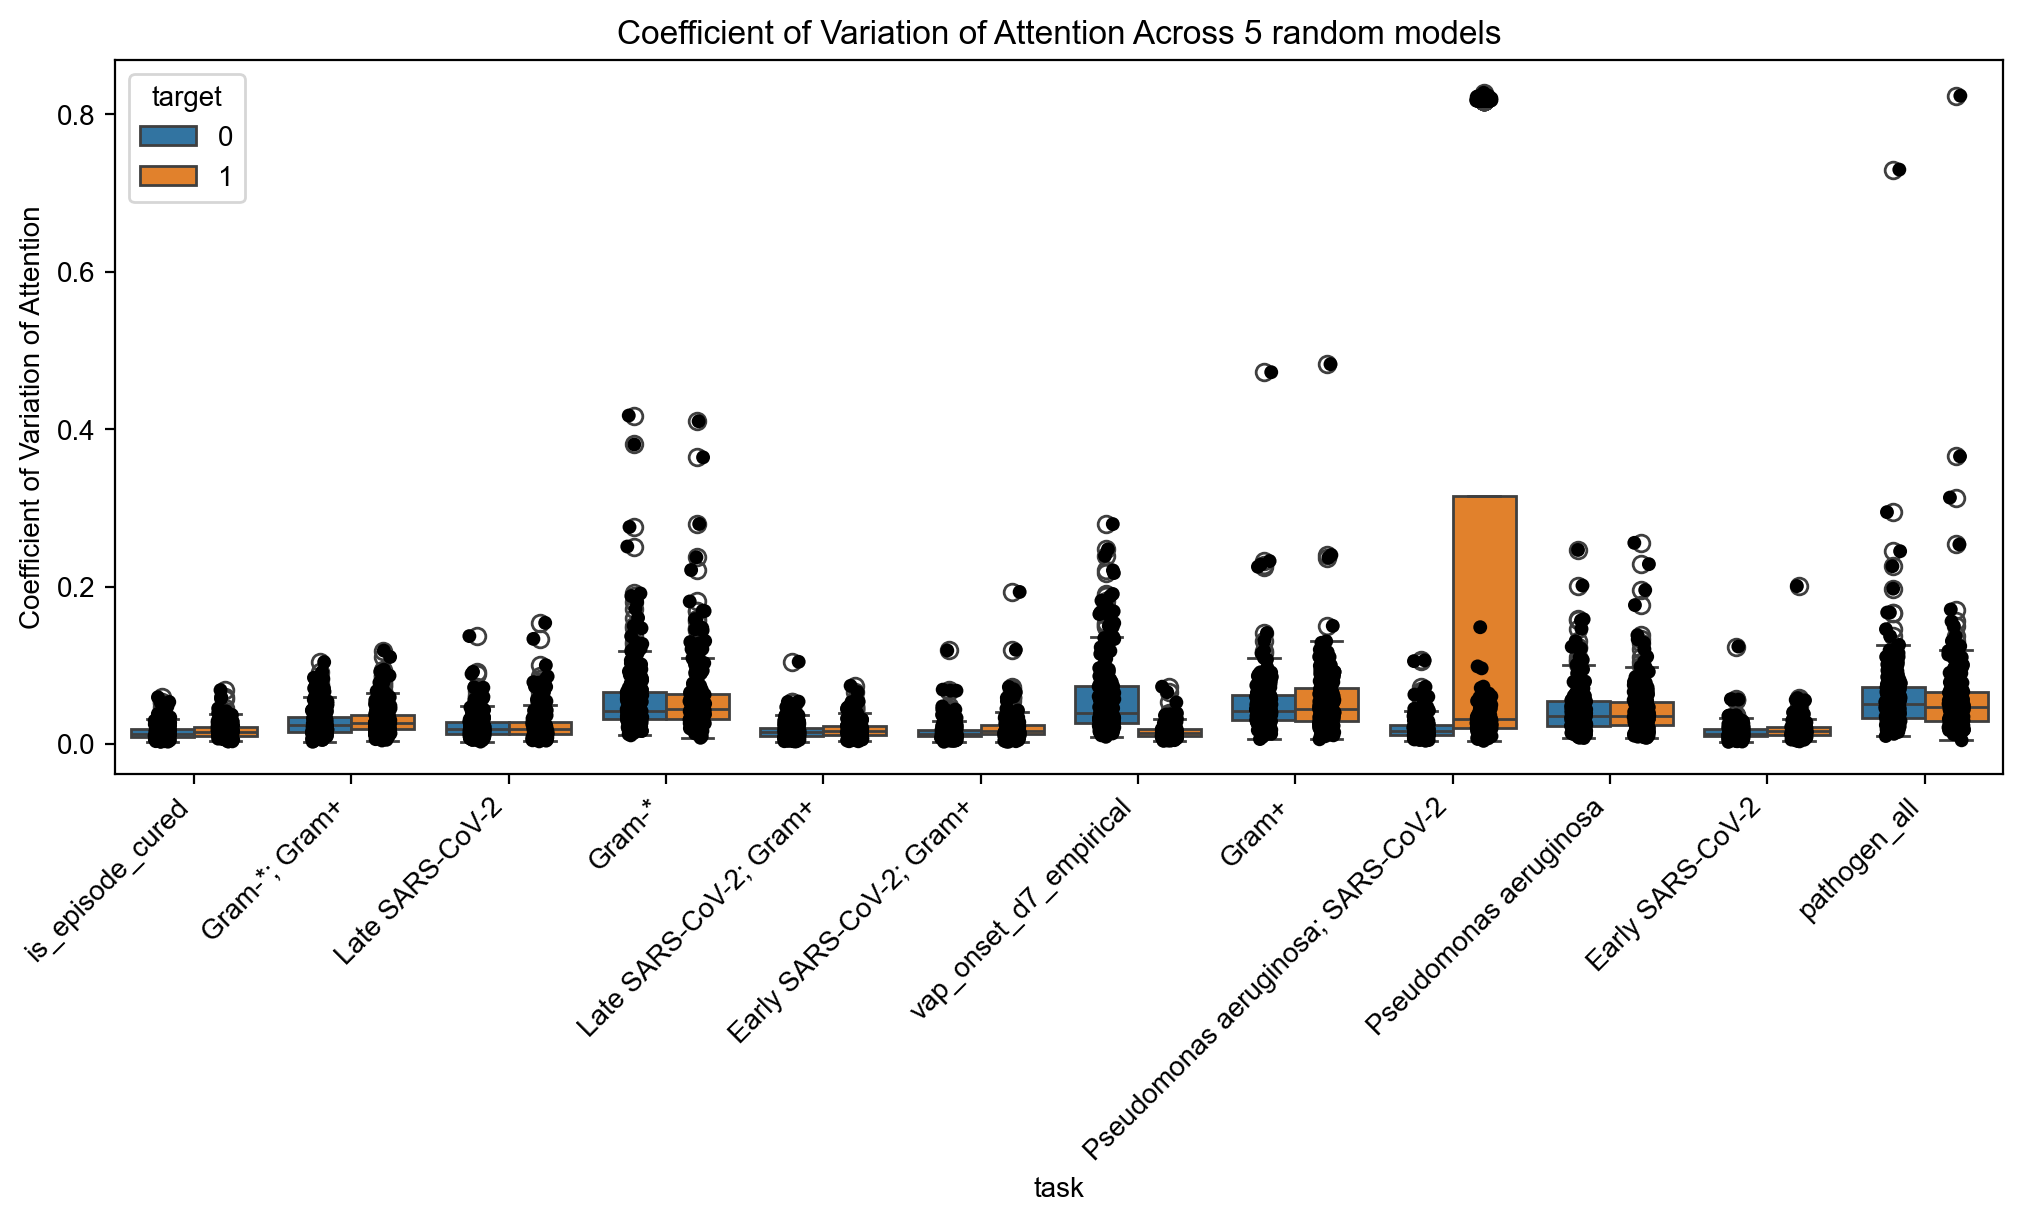

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
sns.boxplot(
    data=summary_df,
    x='task',
    y='cov_attn',
    hue='target',
    ax=ax
)
sns.stripplot(
    data=summary_df,
    x='task',
    y='cov_attn',
    hue='target',
    dodge=True,
    palette=['black'],
    ax=ax,
    legend=False
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Coefficient of Variation of Attention')
ax.set_title('Coefficient of Variation of Attention Across 5 random models')

In [15]:
FEATURES = [col[0] for col in ehr_columns][::5]
assert len(FEATURES) == 50

In [16]:
# Take average attention for each task and split across 5 models
summary_df = []
for task, task_data in results.items():
    for split, split_data in task_data.items():
        attn_values = {}
        for model_idx, model_data in enumerate(split_data):
            for target, (count, attn) in model_data.items():
                if target not in attn_values:
                    attn_values[target] = []
                attn_values[target].append(attn)
        for target, attn_list in attn_values.items():
            attn_array = np.array(attn_list)  # shape (num_models, num_features)
            mean_attn = attn_array.mean(axis=0)
            # renormalize attention without class token
            assert mean_attn.size == 51
            mean_attn = mean_attn[1:] / mean_attn[1:].sum()
            std_attn = attn_array.std(axis=0)[1:]
            for i in range(len(mean_attn)):
                summary_df.append({
                    'task': task.replace(' aeruginosa', ''),
                    'split': split,
                    'target': target,
                    'feature': FEATURES[i],
                    'mean_attn': mean_attn[i],
                    'std_attn': std_attn[i],
                })
summary_df = pd.DataFrame(summary_df)

In [17]:
summary_df = summary_df.groupby(['task', 'target', 'feature']).mean_attn.mean().reset_index()

In [18]:
summary_df = summary_df.pivot_table(
    columns=['target', 'task'],
    index=['feature'],
    values=['mean_attn']
)
summary_df.columns = summary_df.columns.droplevel(0)

In [19]:
summary_df.head()

target                   0                                              \
task      Early SARS-CoV-2 Early SARS-CoV-2; Gram+     Gram+    Gram-*   
feature                                                                  
ABG_PaCO2         0.018590                0.018565  0.016389  0.016638   
ABG_PaO2          0.020998                0.020596  0.019047  0.019258   
ABG_pH            0.020790                0.020346  0.019250  0.018804   
Age               0.022223                0.022750  0.026436  0.030572   
Albumin           0.020295                0.021234  0.023058  0.024598   

target                                                                      \
task      Gram-*; Gram+ Late SARS-CoV-2 Late SARS-CoV-2; Gram+ Pseudomonas   
feature                                                                      
ABG_PaCO2      0.017598        0.018215               0.017777    0.017392   
ABG_PaO2       0.019762        0.020634               0.021063    0.019694   
ABG_pH         0.019436        0.020137               0.020449    0.018899   
Age            0.024752        0.023296               0.022224    0.029918   
Albumin        0.022024        0.021726               0.024462    0.022820   

target                                              ...         1            \
task      Pseudomonas; SARS-CoV-2 is_episode_cured  ...     Gram+    Gram-*   
feature                                             ...                       
ABG_PaCO2                0.018485         0.019829  ...  0.018688  0.018774   
ABG_PaO2                 0.021022         0.018283  ...  0.019756  0.019536   
ABG_pH                   0.020618         0.020698  ...  0.019461  0.018945   
Age                      0.023281         0.021132  ...  0.022535  0.028642   
Albumin                  0.021925         0.018428  ...  0.025056  0.026960   

target                                                                      \
task      Gram-*; Gram+ Late SARS-CoV-2 Late SARS-CoV-2; Gram+ Pseudomonas   
feature                                                                      
ABG_PaCO2      0.019124        0.019797               0.020255    0.017700   
ABG_PaO2       0.019628        0.018643               0.018369    0.020104   
ABG_pH         0.018715        0.018969               0.018990    0.019847   
Age            0.024576        0.023866               0.024064    0.027550   
Albumin        0.024096        0.021230               0.023735    0.023382   

target                                                           \
task      Pseudomonas; SARS-CoV-2 is_episode_cured pathogen_all   
feature                                                           
ABG_PaCO2                0.019908         0.019006     0.021831   
ABG_PaO2                 0.019057         0.020492     0.019319   
ABG_pH                   0.020912         0.024531     0.018997   
Age                      0.020398         0.019850     0.033408   
Albumin                  0.023340         0.019138     0.023675   

target                            
task      vap_onset_d7_empirical  
feature                           
ABG_PaCO2               0.019399  
ABG_PaO2                0.019336  
ABG_pH                  0.022675  
Age                     0.021260  
Albumin                 0.018636  

[5 rows x 24 columns]

In [20]:
PATH_ORDER = [
    'pathogen_all',
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Gram-*',
    'Gram-*; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'Pseudomonas; SARS-CoV-2',
]
COL_ORDER_PATHOGEN = list(itertools.chain(
    [(0, path) for path in PATH_ORDER],
    [(1, path) for path in PATH_ORDER]
))
COL_ORDER_VAP = [
    (0, 'vap_onset_d7_empirical'),
    (0, 'is_episode_cured'),
    (1, 'vap_onset_d7_empirical'),
    (1, 'is_episode_cured')
]

In [21]:
PRETTY_NAMES = {
    'Plateau_Pressure': 'Plateau pressure',
    'Lung_Compliance': 'Lung compliance',
    'Minute_Ventilation': 'Minute ventilation',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'day_of_hospitalization': 'Day of hospitalization',
    'week_of_hospitalization': 'Week of hospitalization',
    'mean_nat_score_until_yesterday': 'Mean NAT score until yesterday',
    'Gender': 'Sex',
    'ICU_stay': 'ICU stay number',
    'GCS_eye_opening': 'GCS eye opening score',
    'GCS_motor_response': 'GCS motor response score',
    'GCS_verbal_response': 'GCS verbal response score',
    'FiO2': r'F$_{\mathrm{i}}$O$_2$',
    'ABG_PaO2': r'P$_{\mathrm{a}}$O$_2$',
    'ABG_pH': 'pH',
    'D_dimer_ff': 'D-dimer',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$'
}
for col in FEATURES:
    if col not in PRETTY_NAMES:
        PRETTY_NAMES[col] = col.replace('_', ' ').replace(' flag', '')

In [22]:
NAMES_PATHOGEN = [
    'Any pathogen',
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Gram+',
    'Pseudomonas',
    'Other Gram–',
    'Other Gram–; Gram+',
    'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+',
    'SARS-CoV-2; Pseudomonas'
]
NAMES_VAP = [
    'VAP onset within 7 days',
    'VAP cure in 7 days',
]

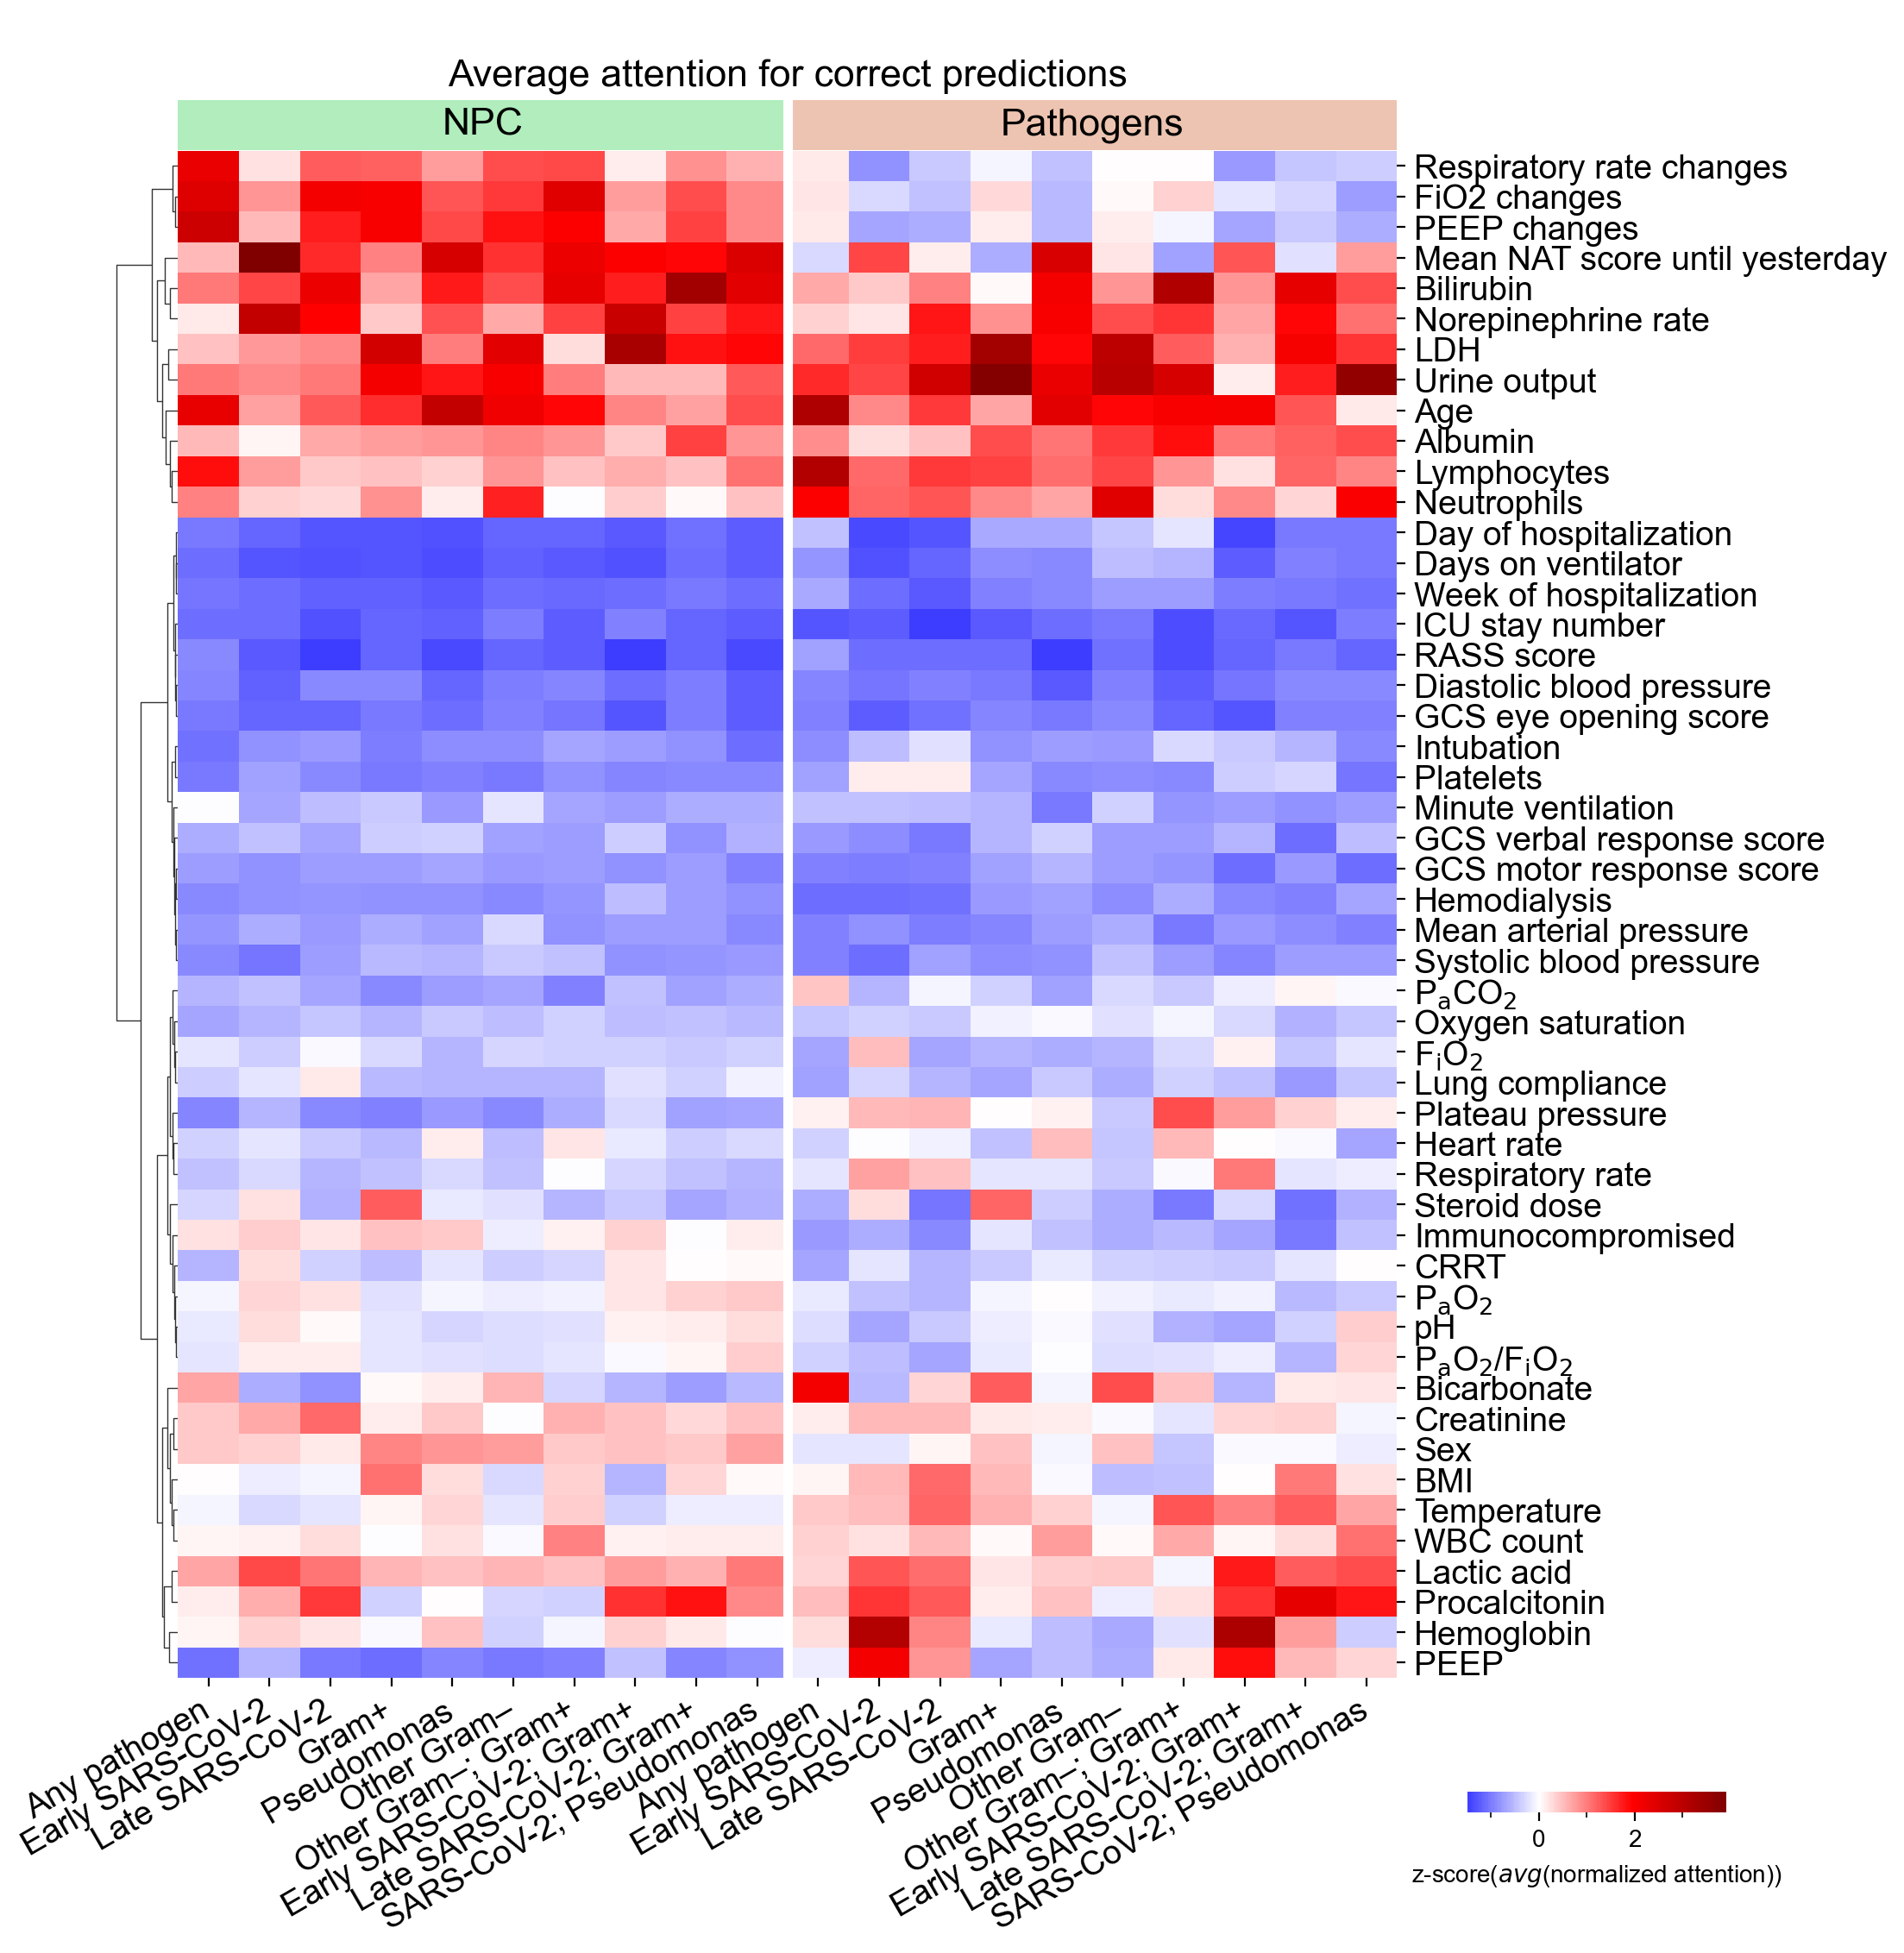

In [ ]:
cg = sns.clustermap(
    summary_df.loc[:, COL_ORDER_PATHOGEN],
    cmap="seismic",
    row_cluster=True,
    col_cluster=False,
    col_colors=['#b1edbd'] * len(PATH_ORDER) + ['#edc4b1'] * len(PATH_ORDER),
    figsize=(10, 12),
    annot=False,
    z_score=1,
    center=0,
    xticklabels=NAMES_PATHOGEN * 2,
    yticklabels=[PRETTY_NAMES.get(idx, idx) for idx in summary_df.index],
    cbar_pos=(0.8, 0.12, 0.15, 0.01),
    cbar_kws=dict(
        label='z-score($avg$(normalized attention))',
        orientation='horizontal',
        # ticks=[-1, 0, 1, 2, 3, 4]
    ),
    dendrogram_ratio=0.05,
    method='ward'
)

cg.ax_cbar.set_xticks([-1, 1, 3], minor=True)

cg.ax_col_colors.set_title('Average attention for correct predictions', size=16)
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')

cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=14)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.axvline(len(PATH_ORDER), c='w', lw=4)
cg.ax_col_colors.axvline(len(PATH_ORDER), c='w', lw=4)

cg.ax_col_colors.text(len(PATH_ORDER) / 2, 0.5, 'NPC', ha='center', va='center', size=16)
cg.ax_col_colors.text(len(PATH_ORDER) * 1.5, 0.5, 'Pathogens', ha='center', va='center', size=16)

cg.savefig('00_plots/Fig_S3g_ehrformer_avg_attn_pathogens.pdf')

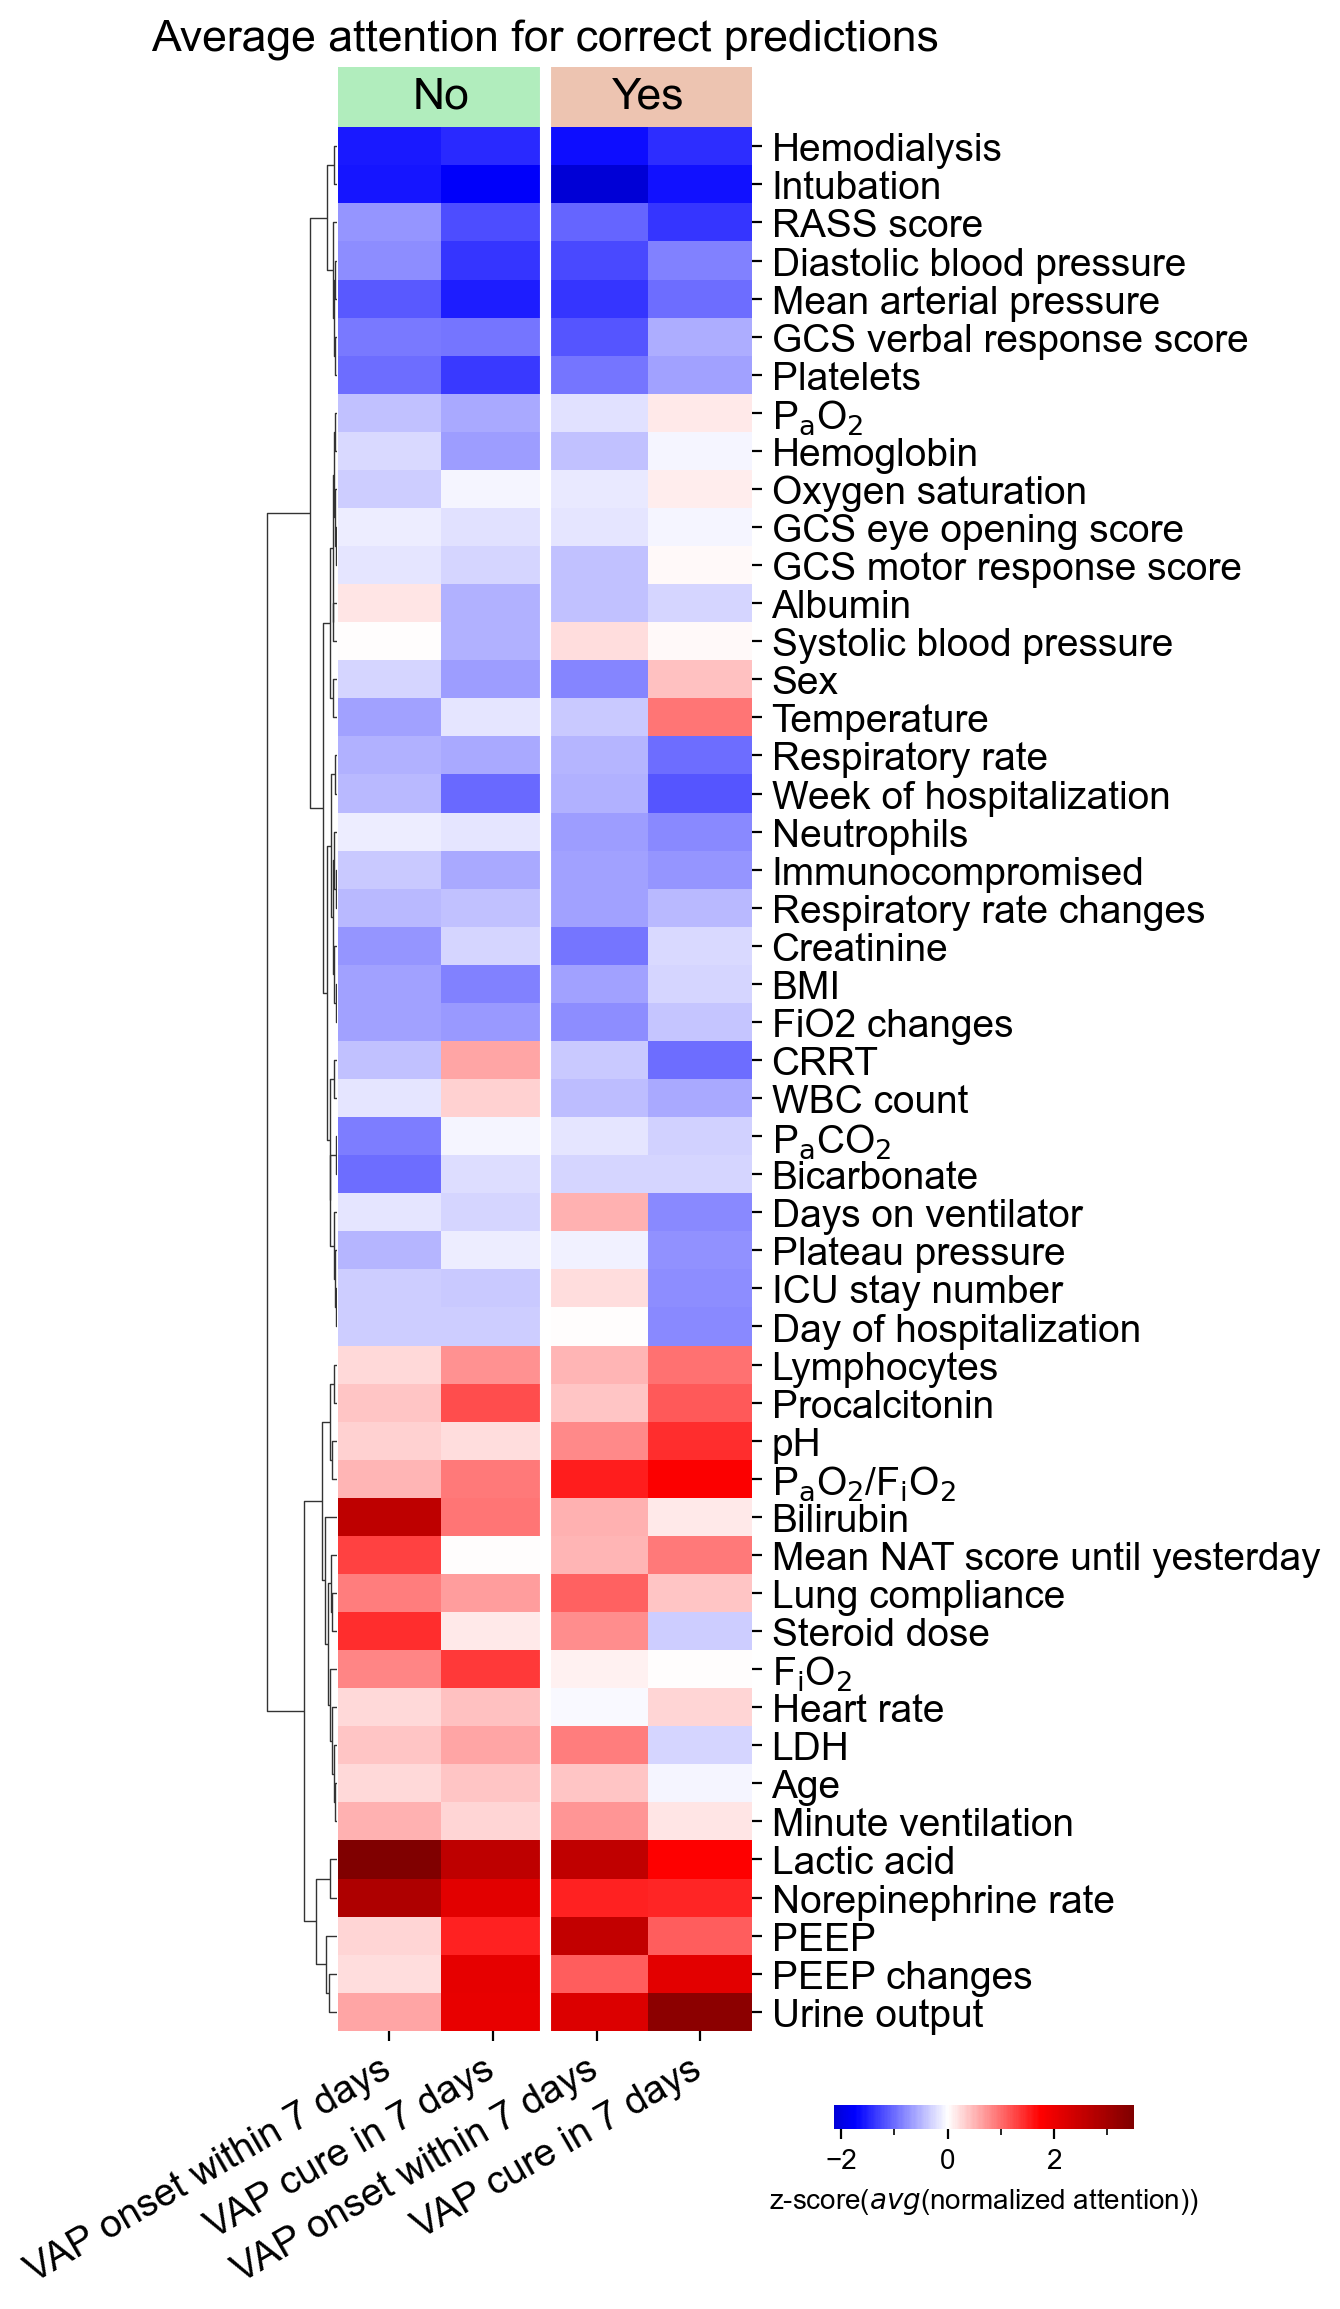

In [ ]:
cg = sns.clustermap(
    summary_df.loc[:, COL_ORDER_VAP],
    cmap="seismic",
    row_cluster=True,
    col_cluster=False,
    col_colors=['#b1edbd'] * len(NAMES_VAP) + ['#edc4b1'] * len(NAMES_VAP),
    figsize=(5, 12),
    annot=False,
    z_score=1,
    center=0,
    xticklabels=NAMES_VAP * 2,
    yticklabels=[PRETTY_NAMES.get(idx, idx) for idx in summary_df.index],
    cbar_pos=(0.6, 0.12, 0.3, 0.01),
    cbar_kws=dict(
        label='z-score($avg$(normalized attention))',
        orientation='horizontal',
        # ticks=[-1, 0, 1, 2, 3, 4]
    ),
    dendrogram_ratio=(0.15, 0.01),
    method='ward'
)

cg.ax_cbar.set_xticks([-1, 1, 3], minor=True)

cg.ax_col_colors.set_title('Average attention for correct predictions', size=16)
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')

cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=14)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.axvline(len(NAMES_VAP), c='w', lw=4)
cg.ax_col_colors.axvline(len(NAMES_VAP), c='w', lw=4)

cg.ax_col_colors.text(len(NAMES_VAP) / 2, 0.5, 'No', ha='center', va='center', size=16)
cg.ax_col_colors.text(len(NAMES_VAP) * 1.5, 0.5, 'Yes', ha='center', va='center', size=16)

cg.savefig('00_plots/Fig_S3h_ehrformer_avg_attn_vap.pdf')